# Set Environment

In [1]:
### Basic
import numpy as np
import scipy as sc
import pickle
import os, sys

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### keras
from keras            import Sequential, models, layers
from keras.utils      import to_categorical
from keras.optimizers import SGD, Adam

### random seed
### ref: https://machinelearningmastery.com/reproducible-results-neural-networks-keras/
from numpy.random import seed
from tensorflow   import set_random_seed

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg        import *
from flowImg_helper import *

### plotting
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')

/local_data/env-py3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
### declare constant
SEED        = 123
N_SAMPLE    = 10
N_SUBSAMPLE = 5
N_EVENT     = 500

N_GRID    = 128
N_CHANNEL = 2
INPUT_SHAPE = (N_GRID, N_GRID, N_CHANNEL)

### directory
DAT_DIR = "/data/clintko/flow_EQAPOL_normal"
FIG_DIR = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image/fig"
RES_DIR = "/data/clintko/flow_EQAPOL_normal/gmm"

In [3]:
import tensorflow as tf
from keras import backend as k
### suppress warning
### ref: https://stackoverflow.com/questions/48608776/how-to-suppress-tensorflow-warning-displayed-in-result
tf.logging.set_verbosity(tf.logging.ERROR)

```
import tensorflow as tf
from keras import backend as k
### suppress warning
### ref: https://stackoverflow.com/questions/48608776/how-to-suppress-tensorflow-warning-displayed-in-result
tf.logging.set_verbosity(tf.logging.ERROR)

### restrict the memory usage of tensorflow
config = tf.ConfigProto()
config.gpu_options.allow_growth = True
k.tensorflow_backend.set_session(tf.Session(config=config))

### ref: https://machinelearningmastery.com/reproducible-results-neural-networks-keras/
from numpy.random import seed
from tensorflow import set_random_seed
```

In [4]:
%matplotlib inline

# Generate data

In [5]:
def gmm(mean, cov, n_events):
    """Generate sample data from gaussian mixed model"""
    ### check data dimension
    assert mean.shape[0] == n_events.shape[0]
    assert mean.shape[0] == cov.shape[0]
    assert mean.shape[1] == cov.shape[1]
    assert mean.shape[1] == cov.shape[2]
    
    ### generate each cluster
    df = [np.random.multivariate_normal(mu, cv, n) 
          for mu, cv, n in zip(mean, cov, n_events)]
    
    ### stack all samples together
    df = np.concatenate(df)
    return df

In [6]:
def generate_sample(mean, cov, num_events):
    """Generate sample data from guassian mixed model"""
    
    dat = np.concatenate(dat)
    return dat

In [7]:
### mean and SD
mu = np.array([[0, 0],[5, 5]])
sd = np.array([np.eye(2), np.eye(2)])

### number of cells
nc1 = np.array([100, 900])            
nc2 = np.array([900, 100])     

### number of samples
ns1 = ns2 = N_SAMPLE

### generate data
np.random.seed(123)
y1  = np.array([gmm(mu, sd, nc1) for _ in range(ns1)])
y2  = np.array([gmm(mu, sd, nc2) for _ in range(ns2)])

### combine the samples and set labels
matrix = np.concatenate([y1, y2])
label  = [0] * ns1 + [1] * ns2 

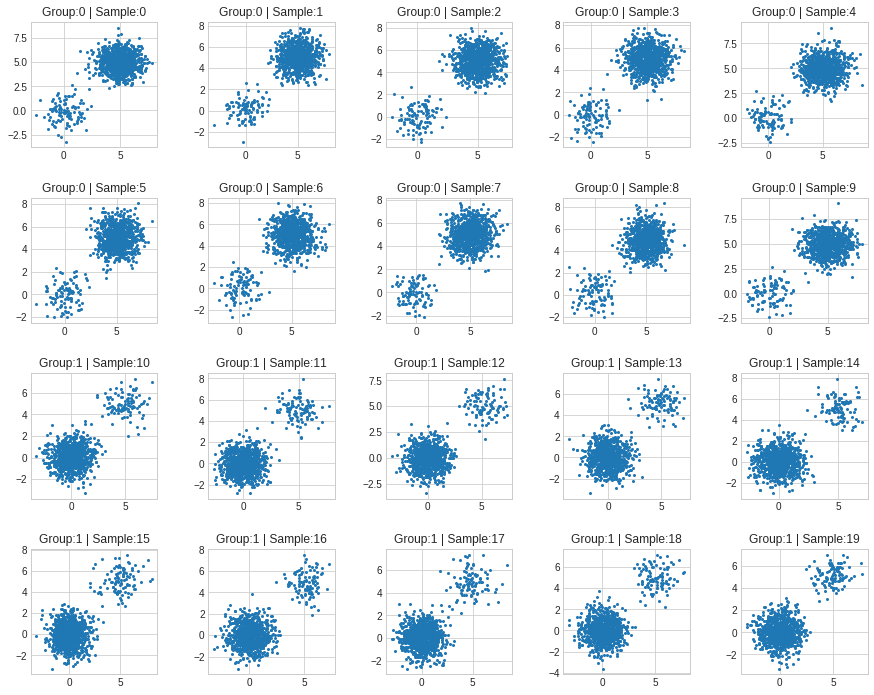

In [8]:
### visualization
fig, axes = plt.subplots(ncols=5, nrows=4, figsize=(3*5, 3*4))
plt.subplots_adjust(wspace = 0.4, hspace = 0.4)
axes = axes.ravel()

for idx, ax in enumerate(axes):
    ax.scatter(matrix[idx][:,0], matrix[idx][:, 1], s = 4)
    ax.set_title("Group:" + str(label[idx]) + " | Sample:" + str(idx))

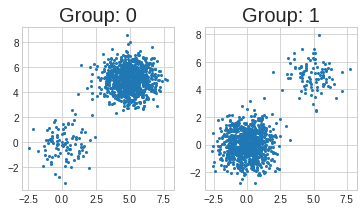

In [9]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(3*2, 3*1))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

idx = 0
axes[0].scatter(matrix[idx][:,0], matrix[idx][:, 1], s = 4)
axes[0].set_title("Group: " + str(label[idx]), fontsize=20)

idx = 11
axes[1].scatter(matrix[idx][:,0], matrix[idx][:, 1], s = 4)
axes[1].set_title("Group: " + str(label[idx]), fontsize=20)

plt.savefig(os.path.join(FIG_DIR, "gmm_run01_scatter.png"), dpi=300)

# Wrap the data

In [10]:
### wrap up the data
print("STEP: wrap up the data")
print("+++++++++++++++++++++++++++++++++++")
%time wrap_data = Data_Wrapper(matrix, label)
print(wrap_data)

STEP: wrap up the data
+++++++++++++++++++++++++++++++++++
CPU times: user 2.29 ms, sys: 1.94 ms, total: 4.22 ms
Wall time: 1.1 ms
Label: Counter({0: 10, 1: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
------------------
Data Matrix: (20000, 2)
    #Samples:   20
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



# Standandization

In [11]:
### Standardize the data
print("STEP: Standardize the data")
print("+++++++++++++++++++++++++++++++++++")
scaler = Transform_StandardScaler(k = 0)
scaler = scaler.fit(wrap_data, verbose = True)
%time wrap_scaled = scaler.transform(wrap_data)
print(wrap_scaled)

STEP: Standardize the data
+++++++++++++++++++++++++++++++++++
Transform_StandardScaler(k=0)
Total Sample: 20
Standardized based on sample: 0

***** k_th Sample: 0 *****
Mean:
[4.47610411 4.49272092]
SD:
[1.75410995 1.81788875]

CPU times: user 1.24 ms, sys: 1.05 ms, total: 2.29 ms
Wall time: 727 µs
Label: Counter({0: 10, 1: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
------------------
Data Matrix: (20000, 2)
    #Samples:   20
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



# Data augmentation

In [12]:
### Subsetting
print("STEP: Subsetting")
print("+++++++++++++++++++++++++++++++++++")
sampler = Transform_Subsampling(n_subsample = N_SUBSAMPLE, n_size = N_EVENT, random_state = SEED)
%time wrap_subs = sampler.fit_transform(wrap_scaled)
print(wrap_subs)

STEP: Subsetting
+++++++++++++++++++++++++++++++++++
CPU times: user 8.89 ms, sys: 4.75 ms, total: 13.6 ms
Wall time: 4.39 ms
Label: Counter({0: 50, 1: 50})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
    1: [50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
 98 99]
------------------
Data Matrix: (50000, 2)
    #Samples:   100
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



# Dimensional reduction

In [13]:
### Dimensional Reduction: t-SNE
print("STEP: Dim.Reduct.")
print("+++++++++++++++++++++++++++++++++++")
tsne = Transform_TSNE(n_components = 2, n_jobs = 12, random_state = SEED)
%time wrap_tsne = tsne.transform(wrap_subs, verbose=True)
print(wrap_tsne)

STEP: Dim.Reduct.
+++++++++++++++++++++++++++++++++++
Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86

In [14]:
mat = wrap_tsne.get_coord(0)
lab = wrap_tsne.label

print(wrap_tsne.get_index(label=0))
print("=========================")
print(wrap_tsne.get_index(label=1))
print("=========================")
print(mat.shape)
print(lab.shape)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
[50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
(500, 2)
(100,)


visualization

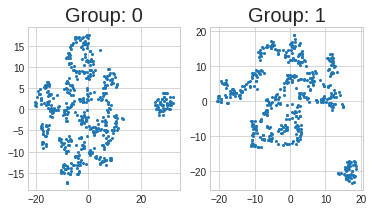

In [15]:
###
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(3*2, 3*1))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

###
lab = wrap_tsne.label

###
idx = 0
mat = wrap_tsne.get_coord(idx)
axes[0].scatter(mat[:,0], mat[:, 1], s = 4)
axes[0].set_title("Group: " + str(lab[idx]), fontsize=20)

idx = 50
mat = wrap_tsne.get_coord(idx)
axes[1].scatter(mat[:,0], mat[:, 1], s = 4)
axes[1].set_title("Group: " + str(lab[idx]), fontsize=20)

plt.savefig(os.path.join(FIG_DIR, "gmm_run01_dimRed.png"), dpi=300)

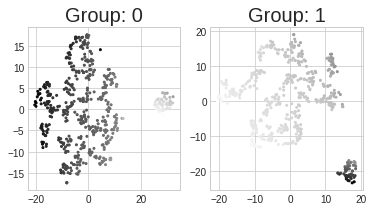

In [16]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(3*2, 3*1))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

ax = axes[0]
wrap_tsne.plot_coord(ax = ax, k = 0,  s = 4)
ax.set_title("Group: " + str(lab[0]), fontsize=20)

ax = axes[1]
wrap_tsne.plot_coord(ax = ax, k = 50, s = 4)
ax.set_title("Group: " + str(lab[50]), fontsize=20)

pass

# Kernel Smoothing

In [17]:
### Kernel Density estimation
print("STEP: Kernel Density estimation")
print("+++++++++++++++++++++++++++++++++++")
density = Transform_Density(sig2 = 5, ngrid = N_GRID)
%time wrap_img = density.transform(wrap_tsne, verbose=True)
print(wrap_img)

STEP: Kernel Density estimation
+++++++++++++++++++++++++++++++++++
Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample:

visualization

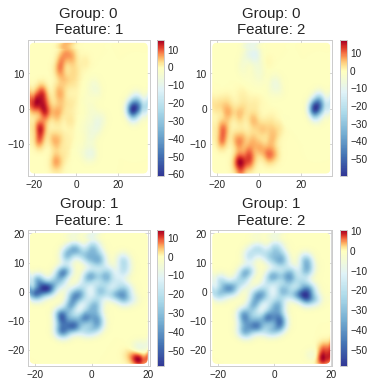

In [18]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(3*2, 3*2))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

axes = axes.ravel()
ax = axes[0]; idx = 0
cax = wrap_img.plot_img(ax, k =  idx, p = 0, cmap = "RdYlBu_r", norm=MidpointNormalize(midpoint=0.))
plt.colorbar(cax, ax = ax)
ax.set_title("Group: " + str(lab[idx]) + "\n" + "Feature: 1", fontsize=15)

ax = axes[1]; idx = 0
cax = wrap_img.plot_img(ax, k =  idx, p = 1, cmap = "RdYlBu_r", norm=MidpointNormalize(midpoint=0.))
plt.colorbar(cax, ax = ax)
ax.set_title("Group: " + str(lab[idx]) + "\n" + "Feature: 2", fontsize=15)

ax = axes[2]; idx = 50
cax = wrap_img.plot_img(ax, k = idx, p = 0, cmap = "RdYlBu_r", norm=MidpointNormalize(midpoint=0.))
plt.colorbar(cax, ax = ax)
ax.set_title("Group: " + str(lab[idx]) + "\n" + "Feature: 1", fontsize=15)

ax = axes[3]; idx = 50
cax = wrap_img.plot_img(ax, k = idx, p = 1, cmap = "RdYlBu_r", norm=MidpointNormalize(midpoint=0.))
plt.colorbar(cax, ax = ax)
ax.set_title("Group: " + str(lab[idx]) + "\n" + "Feature: 2", fontsize=15)

plt.savefig(os.path.join(FIG_DIR, "gmm_run01_ksmooth.png"), dpi=300)
pass

# Store the results

In [19]:
!ls -l /data/clintko/flow_EQAPOL_normal

total 4990548
-rw-r--r-- 1 clintko clintko     240000 Mar 21 21:58 C_1e4.txt
-rw-r--r-- 1 clintko clintko    1232128 Mar 21 16:03 data_cmv_pp65_1e3.npy
-rw-r--r-- 1 clintko clintko   12320128 Mar 21 16:02 data_cmv_pp65_1e4.npy
-rw-r--r-- 1 clintko clintko  123200128 Mar 21 16:00 data_cmv_pp65_1e5.npy
-rw-r--r-- 1 clintko clintko  813533856 Mar 22 23:17 data_cmv_pp65.npy
-rw-r--r-- 1 clintko clintko 1711882471 Mar 22 23:21 data_combine.P
-rw-r--r-- 1 clintko clintko    1232128 Mar 21 16:03 data_costim_1e3.npy
-rw-r--r-- 1 clintko clintko   12320128 Mar 21 16:02 data_costim_1e4.npy
-rw-r--r-- 1 clintko clintko  123200128 Mar 21 16:00 data_costim_1e5.npy
-rw-r--r-- 1 clintko clintko  842536945 Mar 22 23:17 data_costim.npy
-rw-r--r-- 1 clintko clintko    1232128 Mar 21 16:03 data_seb_1e3.npy
-rw-r--r-- 1 clintko clintko   12320128 Mar 21 16:02 data_seb_1e4.npy
-rw-r--r-- 1 clintko clintko  123200128 Mar 21 16:00 data_seb_1e5.npy
-rw-r--r-- 1 clintko clintko  830590564 Mar 22 23:17 data_seb

In [20]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

model_vgg16_lr5e6_bs10_noBNorm.h5		 wrap01_data.P
model_vgg16_lr5e6_bs10_noBNorm_history.P	 wrap02_scaled_k0.P
model_vgg16_lr5e6_bs10_noBNorm.yaml		 wrap03_subs_1e4_N100.P
model_vgg16_lre5_bs10_noBNorm.h5		 wrap03_subs_1e4_N10.P
model_vgg16_noBNorm_lr5e6_bs10_SEB.h5		 wrap03_subs_1e4_N50.P
model_vgg16_noBNorm_lr5e6_bs10_SEB_history.P	 wrap04_tsne_1e4_N10.P
model_vgg16_noBNorm_lr5e6_bs10_SEB.yaml		 wrap04_tsne_1e4_N50.P
model_vgg16_noBNorm_lr5e6_bs50_class3.h5	 wrap05_img_1e4_N50_var01.P
model_vgg16_noBNorm_lr5e6_bs50_class3_history.P  wrap05_img_1e4_N50_var10.P
model_vgg16_noBNorm_lr5e6_bs50_class3.yaml	 wrap05_img_1e4_var01.P
model_vgg16_noBNorm_lr5e6_bs50_SEB.h5		 wrap05_img_1e4_var02.P
model_vgg16_noBNorm_lr5e6_bs50_SEB_history.P	 wrap05_img_1e4_var05.P
model_vgg16_noBNorm_lr5e6_bs50_SEB.yaml		 wrap05_img_1e4_var10.P


In [21]:
fname = os.path.join(RES_DIR, "wrap_img.P")
with open(fname, "wb") as file:
    pickle.dump(wrap_img, file)

In [22]:
!ls '/data/clintko/flow_EQAPOL_normal/gmm'

wrap_img.P


# Logistic Regression and leave one out

### Test one split

In [20]:
dat_img_train, dat_img_test = leave_one_out_split(wrap_img, 0, N_SAMPLE, N_SUBSAMPLE)
print(dat_img_train)
print(dat_img_test)

Label: Counter({0: 45, 1: 45})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44]
    1: [45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68
 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89]
------------------
Data Matrix: (9000, 2)
    #Samples:   90
    #Variables: 2
------------------
Coordinate: (9000, 2)
------------------
Image: (90, 16384, 2)

Label: Counter({0: 5, 1: 5})
    0: [0 1 2 3 4]
    1: [5 6 7 8 9]
------------------
Data Matrix: (1000, 2)
    #Samples:   10
    #Variables: 2
------------------
Coordinate: (1000, 2)
------------------
Image: (10, 16384, 2)



In [21]:
### Perform PCA and logistic regression
print("STEP: Perform PCA and logistic regression: Train/Test")
print("+++++++++++++++++++++++++++++++++++")
pca_logreg = Classify_PCA_LogReg(dat_img_train, pca_explained_ratio = 0.9)
%time pca_logreg = pca_logreg.fit(dat_img_train)
print("===================================")
res = pca_logreg.predict(dat_img_test)
print(list(res.keys()))
print(res['acc'])
print('predicted_class:', res['predicted_class'].shape)
print('predicted_prob: ', res['predicted_prob'].shape)
print('predicted_score:', res['predicted_score'].shape)
print("===================================")
print(res['predicted_class'])
print(dat_img_test.label)

STEP: Perform PCA and logistic regression: Train/Test
+++++++++++++++++++++++++++++++++++
PCA explained ratio:    0.908
PCA num components:     3
Original    data shape: (90, 32768)
PCA reduced data shape: (90, 3)
Log.Reg. Accuracy:      1.0
CPU times: user 3.76 s, sys: 3.89 s, total: 7.65 s
Wall time: 462 ms
['acc', 'predicted_class', 'predicted_prob', 'predicted_score']
1.0
predicted_class: (10,)
predicted_prob:  (10, 2)
predicted_score: (10,)
[0 0 0 0 0 1 1 1 1 1]
[0 0 0 0 0 1 1 1 1 1]


### Leave one out

In [22]:
kargs = dict(pca_explained_ratio = 0.9)
fprs, tprs, roc_aucs = kfold(wrap_img, Classify_PCA_LogReg, kargs, N_SAMPLE, N_SUBSAMPLE)

kfold: k = 0
	Fit & Predict
	ROC
kfold: k = 1
	Fit & Predict
	ROC
kfold: k = 2
	Fit & Predict
	ROC
kfold: k = 3
	Fit & Predict
	ROC
kfold: k = 4
	Fit & Predict
	ROC
kfold: k = 5
	Fit & Predict
	ROC
kfold: k = 6
	Fit & Predict
	ROC
kfold: k = 7
	Fit & Predict
	ROC
kfold: k = 8
	Fit & Predict
	ROC
kfold: k = 9
	Fit & Predict
	ROC


### Evaluating Performance

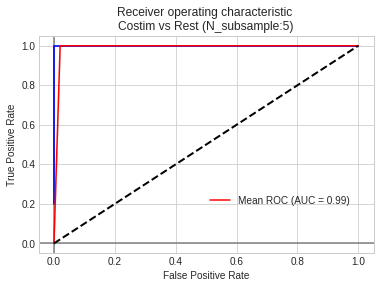

In [24]:
###
idx_class = 0
res_roc = pool_roc(fprs, tprs, idx_class)

###
for k in fprs.keys(): 
    fpr     = fprs[k][idx_class]
    tpr     = tprs[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
###
base_fpr     = res_roc["fpr"]
base_tprs_mu = res_roc["tprs_mu"]
base_tprs_up = res_roc["tprs_upper"]
base_tprs_lw = res_roc["tprs_lower"]
base_auc     = res_roc["auc"]

plt.plot(base_fpr, base_tprs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % base_auc)
plt.fill_between(base_fpr, base_tprs_lw, base_tprs_up, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCostim vs Rest (N_subsample:' + str(N_SUBSAMPLE) + ')')
plt.legend(loc=(0.5, 0.2)) 
pass

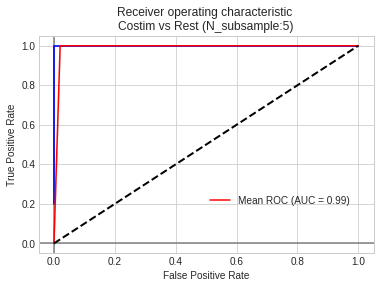

In [25]:
###
idx_class = 1
res_roc = pool_roc(fprs, tprs, idx_class)

###
for k in fprs.keys(): 
    fpr     = fprs[k][idx_class]
    tpr     = tprs[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
###
base_fpr     = res_roc["fpr"]
base_tprs_mu = res_roc["tprs_mu"]
base_tprs_up = res_roc["tprs_upper"]
base_tprs_lw = res_roc["tprs_lower"]
base_auc     = res_roc["auc"]

plt.plot(base_fpr, base_tprs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % base_auc)
plt.fill_between(base_fpr, base_tprs_lw, base_tprs_up, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCostim vs Rest (N_subsample:' + str(N_SUBSAMPLE) + ')')
plt.legend(loc=(0.5, 0.2)) 
pass

# CNN model

In [26]:
def generate_model(input_shape, n_class, lr = 0.000005):
    ### set model
    np.random.seed(SEED)
    set_random_seed(SEED)
    model = Sequential()

    model.add(layers.Conv2D(16, (3, 3), input_shape=input_shape, padding='same', activation='relu'))
    model.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(512,    activation='relu'))
    model.add(layers.Dense(512,    activation='relu'))
    model.add(layers.Dense(n_class, activation='softmax'))

    ### compile the model
    adam = Adam(lr=lr)
    model.compile(
        optimizer=adam,
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    ### name the model
    return model

In [29]:
n_class = len(wrap_img.unique_label())
model = generate_model(INPUT_SHAPE, n_class)
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_5 (Conv2D)            (None, 128, 128, 16)      304       
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 128, 128, 16)      2320      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 64, 64, 16)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 64, 64, 32)        4640      
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 64, 64, 32)        9248      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 32, 32, 32)        0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 32768)             0         
__________

In [ ]:
dat_img_train, dat_img_test = leave_one_out_split(wrap_img, 0, N_SAMPLE, N_SUBSAMPLE)
print(dat_img_train)
print(dat_img_test)

In [30]:
def set_label_onevsrest(label, target):
    label = label.copy()
    label[label != target] = 0
    label[label == target] = 1
    return label

In [32]:
target = 1

In [33]:
img_train = dat_img_train.img
img_train = img_train.reshape((-1, 128, 128, 2))

y_train = dat_img_train.label.copy()
y_train = set_label_onevsrest(y_train, target)
print(y_train)
y_train = to_categorical(y_train)

print(img_train.shape)
print(y_train.shape)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
(90, 128, 128, 2)
(90, 2)


In [34]:
img_test = dat_img_test.img
img_test = img_test.reshape((-1, 128, 128, 2))

y_test = dat_img_test.label.copy()
y_test = set_label_onevsrest(y_test, target)
print(y_test)
y_test = to_categorical(y_test)

print(img_test.shape)
print(y_test.shape)

[0 0 0 0 0 1 1 1 1 1]
(10, 128, 128, 2)
(10, 2)


In [ ]:
history = model.fit(
                img_train, y_train,
                batch_size =  5,
                epochs     = 10,
                verbose    = 1,
                validation_data = (img_test, y_test))

Train on 90 samples, validate on 10 samples
Epoch 1/10


In [122]:
#dat_img   = dat_img
n_classes = len(dat_img.unique_label())
FPR, TPR, ROC_AUC = dict(), dict(), dict()

for idx in range(n_samples):
    print("kfold: k =", idx)
    dat_img_train, dat_img_test = leave_one_out_split(dat_img, idx, n_samples, n_subsamples)
    
    ##############################
    print("\tFit & Predict")
    pca_logreg = Classify_PCA_LogReg(dat_img_train, pca_explained_ratio = 0.9)  
    pca_logreg = pca_logreg.fit(dat_img_train, verbose = 0)
    res = pca_logreg.predict(dat_img_test)
    ##############################
    
    ### calculate fpr and tpr
    print("\tROC")
    y_prob = res['predicted_prob']
    y_test = dat_img_test.label
    y_test = to_categorical(y_test)
    
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    ### store the results
    FPR[idx]     = fpr
    TPR[idx]     = tpr
    ROC_AUC[idx] = roc_auc

kfold: k = 0
	Fit & Predict
	ROC
kfold: k = 1
	Fit & Predict
	ROC
kfold: k = 2
	Fit & Predict
	ROC
kfold: k = 3
	Fit & Predict
	ROC
kfold: k = 4
	Fit & Predict
	ROC
kfold: k = 5
	Fit & Predict
	ROC
kfold: k = 6
	Fit & Predict
	ROC
kfold: k = 7
	Fit & Predict
	ROC
kfold: k = 8
	Fit & Predict
	ROC
kfold: k = 9
	Fit & Predict
	ROC


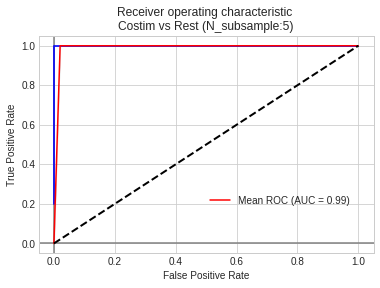

In [123]:
###
idx_class = 0
lw = 2
base_tprs = list()

###
for k in FPR.keys():
    ###
    base_fpr = np.linspace(0, 1, 50)
    
    ###
    fpr     = FPR[k][idx_class]
    tpr     = TPR[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
    ###
    base_tpr = sc.interp(base_fpr, fpr, tpr)
    base_tpr[0] = 0.0
    base_tprs.append(base_tpr)

###
base_tprs    = np.array(base_tprs)

base_tprs_mu = base_tprs.mean(axis=0)
base_tprs_sd = base_tprs.std(axis=0)    

base_tprs_upper = np.minimum(base_tprs_mu + base_tprs_sd, 1)
base_tprs_lower = rocs_mu - rocs_sd

base_auc    = auc(base_fpr, base_tprs_mu)

###
plt.plot(base_fpr, base_tprs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % base_auc)
plt.fill_between(base_fpr, base_tprs_lower, base_tprs_upper, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCostim vs Rest (N_subsample:' + str(N_SUBSAMPLES) + ')')
plt.legend(loc=(0.5, 0.2)) 
pass

In [ ]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(3*2, 3*1))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

idx = 0
axes[0].scatter(matrix[idx][:,0], matrix[idx][:, 1], s = 4)
axes[0].set_title("Group: " + str(label[idx]), fontsize=20)

idx = 11
axes[1].scatter(matrix[idx][:,0], matrix[idx][:, 1], s = 4)
axes[1].set_title("Group: " + str(label[idx]), fontsize=20)

#plt.savefig(os.path.join(FIG_DIR, "scatter_gmm_test01.png"), dpi=300)

In [ ]:
def generate_sample(mean, cov, num_events):
    """Generate sample data from guassian mixed model"""
    assert mean.shape[0] == cov.shape[0]
    assert mean.shape[0] == num_events.shape[0]
    
    num_clusters = mean.shape[0]
    dat = [np.random.multivariate_normal(mean[idx], cov[idx], num_events[idx]) 
           for idx in range(num_clusters)]
    dat = np.concatenate(dat)
    return dat

In [25]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### plotting
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')

### directory
DAT_DIR = "/data/clintko/flow_EQAPOL_normal"

In [2]:
%matplotlib inline

In [3]:
def generate_sample(mean, cov, num_events):
    """Generate sample data from guassian mixed model"""
    assert mean.shape[0] == cov.shape[0]
    assert mean.shape[0] == num_events.shape[0]
    
    num_clusters = mean.shape[0]
    dat = [np.random.multivariate_normal(mean[idx], cov[idx], num_events[idx]) 
           for idx in range(num_clusters)]
    dat = np.concatenate(dat)
    return dat

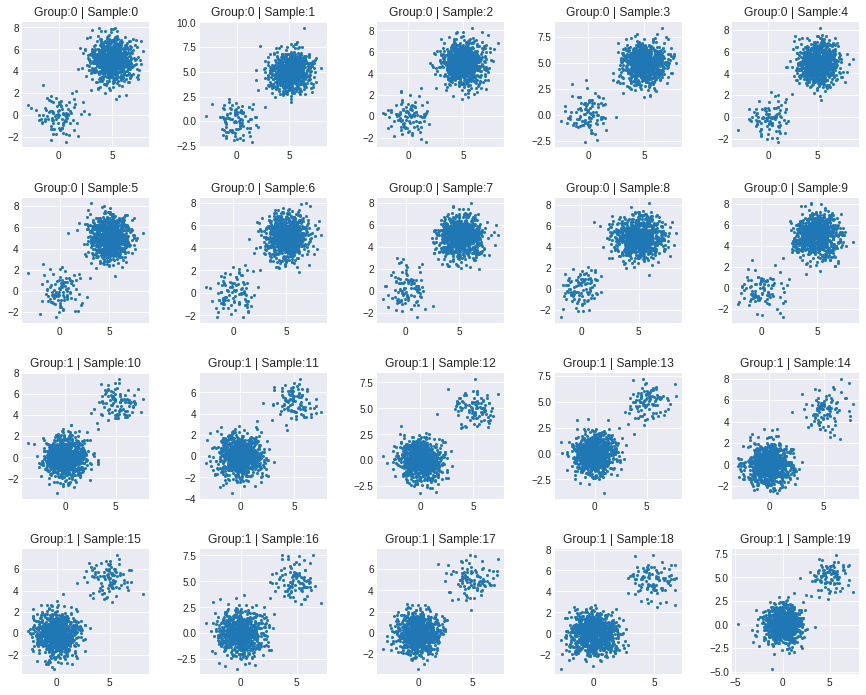

In [4]:
### Generate data
mu1 = np.array([[0, 0],[5, 5]])        ### Mean
sd1 = np.array([np.eye(2), np.eye(2)]) ### SD
nc1 = np.array([100, 900])             ### number of cells
ns1 = 10                               ### number of samples
y1  = np.array([generate_sample(mu1, sd1, nc1) for _ in range(ns1)])

mu2 = np.array([[0, 0],[5, 5]])        ### Mean
sd2 = np.array([np.eye(2), np.eye(2)]) ### SD
nc2 = np.array([900, 100])             ### number of cells
ns2 = 10                               ### number of samples
y2  = np.array([generate_sample(mu2, sd2, nc2) for _ in range(ns2)])

### combine the samples and set labels
matrix = np.concatenate([y1, y2])
label  = [0] * ns1 + [1] * ns2 

### visualization
fig, axes = plt.subplots(ncols=5, nrows=4, figsize = (3*5, 3*4))
plt.subplots_adjust(wspace = 0.4, hspace = 0.4)
axes = axes.ravel()

for idx, ax in enumerate(axes):
    ax.scatter(matrix[idx][:,0], matrix[idx][:, 1], s = 4)
    ax.set_title("Group:" + str(label[idx]) + " | Sample:" + str(idx))

In [5]:
### wrap up the data
print("STEP: wrap up the data")
print("+++++++++++++++++++++++++++++++++++")
%time dat_wrap = Data_Wrapper(matrix, label)
print(dat_wrap)

STEP: wrap up the data
+++++++++++++++++++++++++++++++++++
CPU times: user 0 ns, sys: 3.57 ms, total: 3.57 ms
Wall time: 994 µs
Label: Counter({0: 10, 1: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
------------------
Data Matrix: (20000, 2)
    #Samples:   20
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [6]:
### Standardize the data
print("STEP: Standardize the data")
print("+++++++++++++++++++++++++++++++++++")
scaler = Transform_StandardScaler(k = 0)
scaler = scaler.fit(dat_wrap)
%time dat_scaled = scaler.transform(dat_wrap)
print(dat_scaled)

STEP: Standardize the data
+++++++++++++++++++++++++++++++++++
Transform_StandardScaler(k=0)
Total Sample: 20
Standardized based on sample: 0

***** k_th Sample: 0 *****
Mean:
[4.50466816 4.5471253 ]
SD:
[1.79683324 1.83658308]

CPU times: user 0 ns, sys: 857 µs, total: 857 µs
Wall time: 739 µs
Label: Counter({0: 10, 1: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
------------------
Data Matrix: (20000, 2)
    #Samples:   20
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [7]:
### Subsetting
print("STEP: Subsetting")
print("+++++++++++++++++++++++++++++++++++")
sampler = Transform_Subsampling(n_subsample = 5, n_size = 100, random_state = 123)
%time dat_subs = sampler.fit_transform(dat_scaled)
print(dat_subs)

STEP: Subsetting
+++++++++++++++++++++++++++++++++++
CPU times: user 1.03 ms, sys: 835 µs, total: 1.87 ms
Wall time: 1.58 ms
Label: Counter({0: 50, 1: 50})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
    1: [50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
 98 99]
------------------
Data Matrix: (10000, 2)
    #Samples:   100
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [8]:
### Dimensional Reduction: t-SNE
print("STEP: Dim.Reduct.")
print("+++++++++++++++++++++++++++++++++++")
tsne = Transform_TSNE(n_components = 2, n_jobs = 12, random_state = 123)
%time dat_tsne = tsne.transform(dat_subs, verbose=True)
print(dat_tsne)

STEP: Dim.Reduct.
+++++++++++++++++++++++++++++++++++
Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86

In [9]:
### Kernel Density estimation
print("STEP: Kernel Density estimation")
print("+++++++++++++++++++++++++++++++++++")
density = Transform_Density(sig2 = 5)
%time dat_img = density.transform(dat_tsne, verbose=True)
print(dat_img)

STEP: Kernel Density estimation
+++++++++++++++++++++++++++++++++++
Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample:

In [14]:
### Perform PCA and logistic regression
print("STEP: Perform PCA and logistic regression")
print("+++++++++++++++++++++++++++++++++++")
pca_logreg = Classify_PCA_LogReg(dat_img, pca_explained_ratio = 0.9)
%time pca_logreg = pca_logreg.fit(dat_img)
print("===================================")
res = pca_logreg.predict(dat_img)
print(list(res.keys()))
print(res['acc'])
print(res['predicted_class'].shape)
print(res['predicted_prob'].shape)
print(res['predicted_score'].shape)
print("===================================")
print(res['predicted_class'])
print("===================================")
print(pca_logreg.model.predict(pca_logreg.X_red))
print("===================================")
print(pca_logreg)

STEP: Perform PCA and logistic regression
+++++++++++++++++++++++++++++++++++
PCA explained ratio:    0.914
PCA num components:     4
Original    data shape: (100, 32768)
PCA reduced data shape: (100, 4)
Log.Reg. Accuracy:      1.0
CPU times: user 5.01 s, sys: 2.76 s, total: 7.78 s
Wall time: 406 ms
['acc', 'predicted_class', 'predicted_prob', 'predicted_score']
1.0
(100,)
(100, 2)
(100,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Classify_PCA_LogReg(classifier=None, dat=None, pca_explained_ratio=None,
          random_state=None)


In [16]:
dat_img_train, dat_img_test = train_test_split_datawrapper(
    dat_img, 8, 5)
print(dat_img_train)
print(dat_img_test)

Label: Counter({0: 40, 1: 40})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
    1: [40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63
 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79]
------------------
Data Matrix: (8000, 2)
    #Samples:   80
    #Variables: 2
------------------
Coordinate: (8000, 2)
------------------
Image: (80, 16384, 2)

Label: Counter({0: 10, 1: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
------------------
Data Matrix: (2000, 2)
    #Samples:   20
    #Variables: 2
------------------
Coordinate: (2000, 2)
------------------
Image: (20, 16384, 2)



In [21]:
### Perform PCA and logistic regression
print("STEP: Perform PCA and logistic regression: Train/Test")
print("+++++++++++++++++++++++++++++++++++")
pca_logreg = Classify_PCA_LogReg(dat_img_train, pca_explained_ratio = 0.9)
%time pca_logreg = pca_logreg.fit(dat_img_train)
print("===================================")
res = pca_logreg.predict(dat_img_test)
print(list(res.keys()))
print(res['acc'])
print('predicted_class:', res['predicted_class'].shape)
print('predicted_prob: ', res['predicted_prob'].shape)
print('predicted_score:', res['predicted_score'].shape)
print("===================================")
print(res['predicted_class'])
print(dat_img_test.label)

STEP: Perform PCA and logistic regression: Train/Test
+++++++++++++++++++++++++++++++++++
PCA explained ratio:    0.915
PCA num components:     4
Original    data shape: (80, 32768)
PCA reduced data shape: (80, 4)
Log.Reg. Accuracy:      1.0
CPU times: user 3.67 s, sys: 3.12 s, total: 6.79 s
Wall time: 338 ms
['acc', 'predicted_class', 'predicted_prob', 'predicted_score']
1.0
predicted_class: (20,)
predicted_prob:  (20, 2)
predicted_score: (20,)
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


STEP: ROC curve
+++++++++++++++++++++++++++++++++++


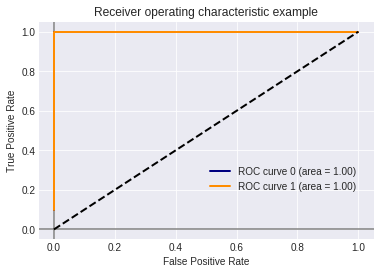

In [29]:
# Compute ROC curve and ROC area for each class
print("STEP: ROC curve")
print("+++++++++++++++++++++++++++++++++++")

### init
fpr, tpr, roc_auc = dict(), dict(), dict()
n_classes = len(dat_img.unique_label())

### get label: test data and predicted
res = pca_logreg.predict(dat_img_test)
y_prob = res['predicted_prob']
y_test = dat_img_test.label
y_test = to_categorical(y_test)

### calculate fpr and tpr
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

### Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

#######################################################

### set plot
plt.figure()
lw = 2

### since there is only two classes, below are the same
plt.plot(fpr[0], tpr[0], color='navy',       lw=lw, label='ROC curve 0 (area = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkorange', lw=lw, label='ROC curve 1 (area = %0.2f)' % roc_auc[1])
#plt.plot(fpr[2], tpr[2], color='darkred',    lw=lw, label='ROC curve 2 (area = %0.2f)' % roc_auc[2])

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc=(0.5, 0.2)) #plt.legend(loc="lower right")

plt.show()